<a href="https://colab.research.google.com/github/rania-532/projet-deep-learning-4IAD/blob/main/deep-learning-4IAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Monter Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
print(os.listdir('/content/drive'))

['.shortcut-targets-by-id', 'MyDrive', '.Trash-0', '.Encrypted']


## Partie I : MLP et Ingénierie PyTorch  
Un Perceptron Multicouche (MLP) est le réseau de neurones le plus fondamental. Il est composé de couches entièrement connectées : chaque neurone est relié à tous les neurones de la couche suivante.

 **Pourquoi un MLP pour les données tabulaires ?**

Les données tabulaires n'ont pas de structure spatiale (pas d'images) ni de séquence temporelle. Un MLP est parfait car il peut apprendre des relations non-linéaires entre des variables indépendantes.  **Concepts clés :** - `nn.Module` : classe de base de PyTorch pour tous les modèles - Propagation avant : le signal va de l'entrée vers la sortie - Rétropropagation : le gradient va de la sortie vers l'entrée - `state_dict()` : dictionnaire contenant tous les paramètres du modèle

In [10]:
# === CELLULE 2 : Imports ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# Vérification GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')


Device utilisé : cuda


In [6]:
# === CELLULE 3 : Préparation des données ===

# 1. Chargement — Wine Quality depuis sklearn
wine = load_wine()
X, y = wine.data, wine.target
print(f'Forme des données : {X.shape}')  # (178, 13)
print(f'Classes : {wine.target_names}')
print(f'Variables : {wine.feature_names}')

# 2. Analyse exploratoire
df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y
print(df.describe())
print('Distribution des classes:', df['target'].value_counts())

# 3. Normalisation — OBLIGATOIRE pour les MLP
# Pourquoi ? Les variables ont des échelles très différentes.
# Ex: alcool (9-15) vs acide malique (0-5). Sans normalisation,
# le gradient favorise les grandes variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Séparation train/val/test (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

# 5. Conversion en tenseurs PyTorch
def to_tensor(X, y):
    return (torch.FloatTensor(X).to(device),
            torch.LongTensor(y).to(device))

X_tr, y_tr = to_tensor(X_train, y_train)
X_v,  y_v  = to_tensor(X_val,   y_val)
X_te, y_te = to_tensor(X_test,  y_test)

# 6. DataLoaders
train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),  batch_size=32)


Forme des données : (178, 13)
Classes : ['class_0' 'class_1' 'class_2']
Variables : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols 

In [7]:
# === CELLULE 4 : Les deux versions du MLP ===

# ----- Version 1 : nn.Sequential -----
# Avantage : concis, lisible pour des architectures simples
# Inconvénient : pas de flexibilité (pas de skip connections, etc.)

mlp_sequential = nn.Sequential(
    nn.Linear(13, 64),   # 13 entrées (features Wine)
    nn.ReLU(),
    nn.Dropout(0.3),     # Régularisation : évite le surapprentissage
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(32, 3)     # 3 classes de sortie
).to(device)

# ----- Version 2 : Classe personnalisée -----
# Avantage : contrôle total, on peut ajouter des méthodes custom
# C'est la manière professionnelle d'implémenter un réseau

class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.3):
        super(MLP, self).__init__()
        # Construction dynamique des couches
        layers = []
        prev_dim = input_dim
        for dim in hidden_dims:
            layers += [nn.Linear(prev_dim, dim), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = dim
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

mlp_custom = MLP(input_dim=13, hidden_dims=[64, 32], output_dim=3).to(device)
print('Architecture MLP custom:')
print(mlp_custom)
print(f'Nombre de paramètres: {sum(p.numel() for p in mlp_custom.parameters()):,}')


Architecture MLP custom:
MLP(
  (network): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)
Nombre de paramètres: 3,075


In [8]:
# === CELLULE 5 : Inspection avec named_parameters() et state_dict() ===

print('=== named_parameters() ===')
for name, param in mlp_custom.named_parameters():
    print(f'{name:40s} | shape: {str(param.shape):20s} | trainable: {param.requires_grad}')

print()
print('=== state_dict() — premières valeurs ===')
for key, val in mlp_custom.state_dict().items():
    print(f'{key:40s} -> {val.shape}')


=== named_parameters() ===
network.0.weight                         | shape: torch.Size([64, 13]) | trainable: True
network.0.bias                           | shape: torch.Size([64])     | trainable: True
network.3.weight                         | shape: torch.Size([32, 64]) | trainable: True
network.3.bias                           | shape: torch.Size([32])     | trainable: True
network.6.weight                         | shape: torch.Size([3, 32])  | trainable: True
network.6.bias                           | shape: torch.Size([3])      | trainable: True

=== state_dict() — premières valeurs ===
network.0.weight                         -> torch.Size([64, 13])
network.0.bias                           -> torch.Size([64])
network.3.weight                         -> torch.Size([32, 64])
network.3.bias                           -> torch.Size([32])
network.6.weight                         -> torch.Size([3, 32])
network.6.bias                           -> torch.Size([3])


In [9]:
# === CELLULE 6 : Trois stratégies d'initialisation ===

def init_weights(model, strategy='xavier'):
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if strategy == 'gaussian':
                nn.init.normal_(m.weight, mean=0, std=0.01)
                nn.init.zeros_(m.bias
            elif strategy == 'constant':
                nn.init.constant_(m.weight, 0.01)
                nn.init.zeros_(m.bias)
            elif strategy == 'xavier':
                nn.init.xavier_uniform_(m.weight)  # Meilleure pratique
                nn.init.zeros_(m.bias)

# Test des trois stratégies
results_init = {}
for strategy in ['gaussian', 'constant', 'xavier']:
    model = MLP(input_dim=13, hidden_dims=[64,32], output_dim=3).to(device)
    init_weights(model, strategy)
    # Entraînement rapide (5 epochs pour comparer)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    losses = []
    for epoch in range(5):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            losses.append(loss.item())
    results_init[strategy] = np.mean(losses[-10:])
    print(f'{strategy:12s} | loss finale (moy): {results_init[strategy]:.4f}')


gaussian     | loss finale (moy): 1.0893
constant     | loss finale (moy): 1.0567
xavier       | loss finale (moy): 0.9557


In [10]:
# === CELLULE 7 : Entraînement avec le meilleur modèle ===

model = MLP(input_dim=13, hidden_dims=[64, 32], output_dim=3).to(device)
init_weights(model, 'xavier')
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10)

train_losses, val_losses, val_accs = [], [], []
best_val_acc = 0
EPOCHS = 100

for epoch in range(EPOCHS):
    # --- Phase entraînement ---
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # --- Phase validation ---
    model.eval()
    with torch.no_grad():
        val_preds = model(X_v)
        val_loss = criterion(val_preds, y_v).item()
        val_acc = (val_preds.argmax(1) == y_v).float().mean().item()
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    scheduler.step(val_loss)

    # --- Sauvegarde du meilleur modèle ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_mlp.pth')

    if (epoch+1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Loss train: {train_losses[-1]:.4f} | Loss val: {val_loss:.4f} | Acc val: {val_acc:.4f}')


Epoch  20 | Loss train: 0.2454 | Loss val: 0.1496 | Acc val: 1.0000
Epoch  40 | Loss train: 0.0972 | Loss val: 0.0451 | Acc val: 1.0000
Epoch  60 | Loss train: 0.0308 | Loss val: 0.0231 | Acc val: 1.0000
Epoch  80 | Loss train: 0.0325 | Loss val: 0.0154 | Acc val: 1.0000
Epoch 100 | Loss train: 0.0086 | Loss val: 0.0138 | Acc val: 1.0000


=== Métriques sur l ensemble de test ===
Accuracy  : 0.9259
Precision : 0.9327
Recall    : 0.9327
F1-Score  : 0.9327


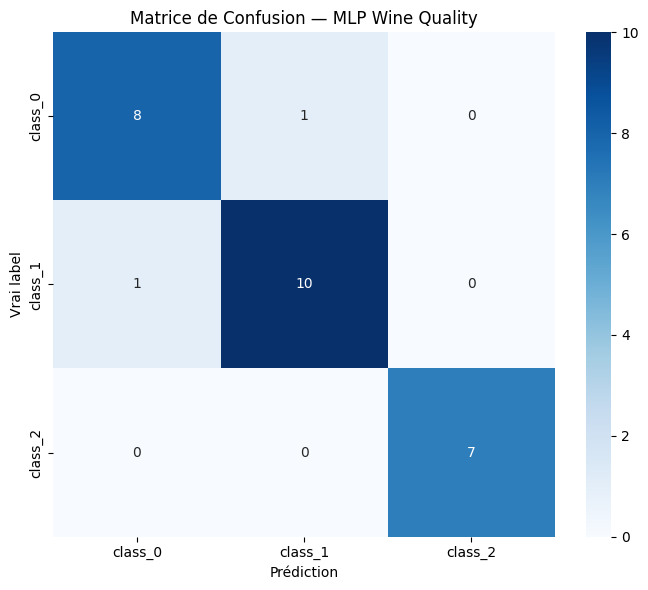

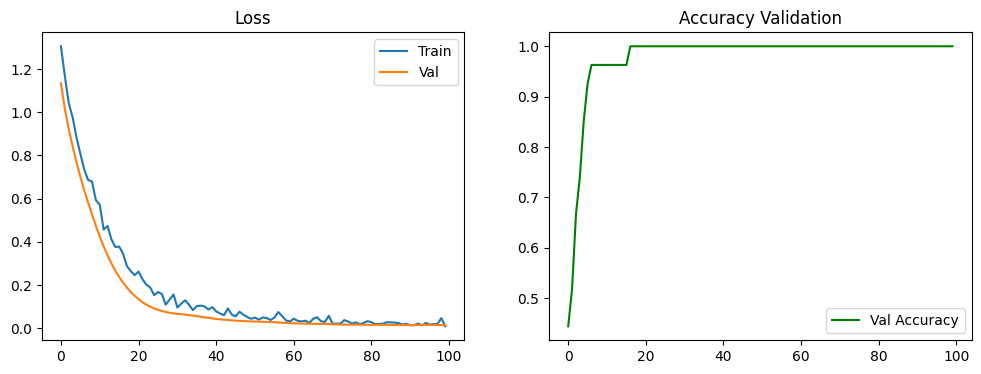

In [11]:
# === CELLULE 8 : Recharger le meilleur modèle et évaluer ===

best_model = MLP(input_dim=13, hidden_dims=[64, 32], output_dim=3).to(device)
best_model.load_state_dict(torch.load('/content/drive/MyDrive/best_mlp.pth'))
best_model.eval()

with torch.no_grad():
    test_preds = best_model(X_te).argmax(1).cpu().numpy()
    y_true = y_te.cpu().numpy()

print('=== Métriques sur l ensemble de test ===')
print(f'Accuracy  : {accuracy_score(y_true, test_preds):.4f}')
print(f'Precision : {precision_score(y_true, test_preds, average="macro"):.4f}')
print(f'Recall    : {recall_score(y_true, test_preds, average="macro"):.4f}')
print(f'F1-Score  : {f1_score(y_true, test_preds, average="macro"):.4f}')

# Matrice de confusion
cm = confusion_matrix(y_true, test_preds)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=wine.target_names, yticklabels=wine.target_names)
plt.title('Matrice de Confusion — MLP Wine Quality')
plt.ylabel('Vrai label'); plt.xlabel('Prédiction')
plt.tight_layout(); plt.savefig('confusion_mlp.png', dpi=150); plt.show()

# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(val_accs, label='Val Accuracy', color='green')
ax2.set_title('Accuracy Validation'); ax2.legend()
plt.savefig('learning_curves_mlp.png', dpi=150); plt.show()


Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites ?

## Partie II : CNN et Vision par Ordinateur  ###
Pourquoi pas un MLP pour les images ? Une image 28x28 = 784 pixels. Si on la passe dans un MLP, on la 'aplatit' et on perd toute structure spatiale. Deux pixels adjacents ne sont plus traités différemment de deux pixels éloignés.  
### Les 3 idées clés du CNN :
1. **Localité** : les filtres regardent une petite région (3x3, 5x5) — un pixel est influencé par ses voisins
2. **Partage des poids** : le même filtre est appliqué partout dans l'image (translation invariance)
3. **Hiérarchie** : couche 1 = contours, couche 2 = formes simples, couche 3 = parties d'objets  

### Calcul de la taille de sortie :
 `taille_out = floor((taille_in + 2*padding - kernel_size) / stride) + 1`

In [1]:
# === CELLULE 2 : Calculs dimensionnels ===

def conv_output_size(input_size, kernel_size, padding=0, stride=1):
    return (input_size + 2*padding - kernel_size) // stride + 1

def pool_output_size(input_size, pool_size=2, stride=None):
    if stride is None: stride = pool_size
    return (input_size - pool_size) // stride + 1

print('=== Calculs pour Fashion-MNIST (28x28) ===')
# Conv1: kernel=5, padding=0, stride=1
out1 = conv_output_size(28, kernel_size=5, padding=0, stride=1)
print(f'Après Conv1 (k=5, p=0, s=1): {out1}x{out1}')  # 24x24
out1p = pool_output_size(out1, pool_size=2)
print(f'Après MaxPool (2x2): {out1p}x{out1p}')  # 12x12
out2 = conv_output_size(out1p, kernel_size=5, padding=0, stride=1)
print(f'Après Conv2 (k=5, p=0, s=1): {out2}x{out2}')  # 8x8
out2p = pool_output_size(out2, pool_size=2)
print(f'Après MaxPool (2x2): {out2p}x{out2p}')  # 4x4
print(f'Taille après aplatissement: 16 filtres * {out2p}*{out2p} = {16*out2p*out2p}')


=== Calculs pour Fashion-MNIST (28x28) ===
Après Conv1 (k=5, p=0, s=1): 24x24
Après MaxPool (2x2): 12x12
Après Conv2 (k=5, p=0, s=1): 8x8
Après MaxPool (2x2): 4x4
Taille après aplatissement: 16 filtres * 4*4 = 256


In [9]:
# === CELLULE 3 : Corrélation croisée, max-pool, avg-pool MANUELS ===

import torch.nn.functional as F

def corr2d_manual(X, K):
    '''Corrélation croisée 2D — implémentation from scratch'''
    h_out = X.shape[0] - K.shape[0] + 1
    w_out = X.shape[1] - K.shape[1] + 1
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i, j] = (X[i:i+K.shape[0], j:j+K.shape[1]] * K).sum()
    return Y

def maxpool_manual(X, pool_size=2):
    '''Max Pooling 2D from scratch'''
    h_out = X.shape[0] // pool_size
    w_out = X.shape[1] // pool_size
    Y = torch.zeros(h_out, w_out)
    for i in range(h_out):
        for j in range(w_out):
            Y[i,j] = X[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size].max()
    return Y

# Test et comparaison avec PyTorch
X_test_img = torch.randn(6, 6)
K_test = torch.tensor([[1.0, 0], [0, -1]])
manual_out = corr2d_manual(X_test_img, K_test)
pytorch_out = F.conv2d(X_test_img.unsqueeze(0).unsqueeze(0), K_test.unsqueeze(0).unsqueeze(0))
print('Manuel:', manual_out.shape, '| PyTorch:', pytorch_out.squeeze().shape)
print('Identiques ?', torch.allclose(manual_out, pytorch_out.squeeze(), atol=1e-5))


Manuel: torch.Size([5, 5]) | PyTorch: torch.Size([5, 5])
Identiques ? True


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 179kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.32MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 28.3MB/s]


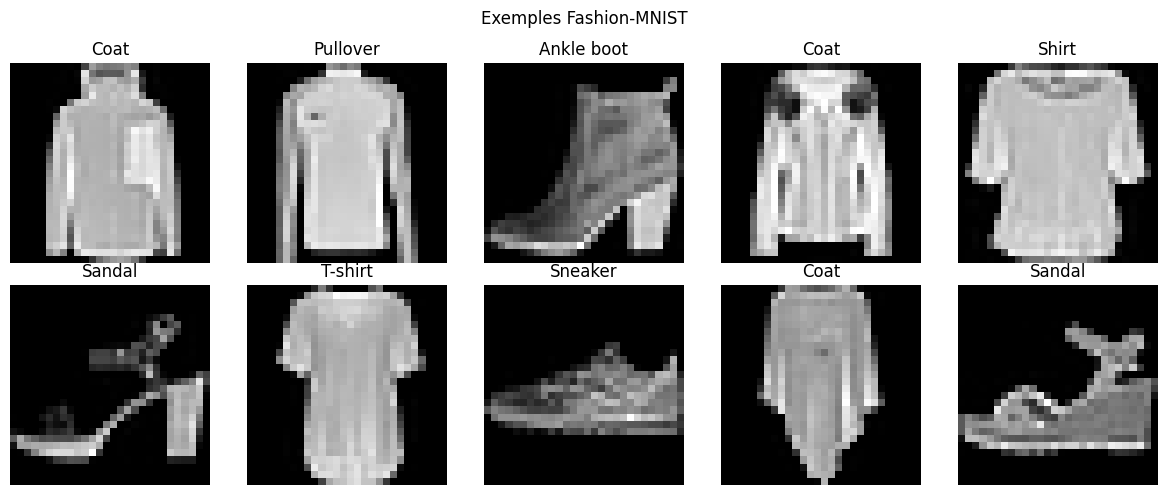

In [4]:
# === CELLULE 4 : Fashion-MNIST avec torchvision ===

import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Moyenne/std Fashion-MNIST
])

train_data = torchvision.datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=64, shuffle=False, num_workers=2)

classes = ['T-shirt','Trouser','Pullover','Dress','Coat',
           'Sandal','Shirt','Sneaker','Bag','Ankle boot']

# Visualisation de quelques exemples
imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i].squeeze(), cmap='gray')
    ax.set_title(classes[labels[i]])
    ax.axis('off')
plt.suptitle('Exemples Fashion-MNIST'); plt.tight_layout(); plt.show()


In [5]:
# === CELLULE 5 : CNN inspiré de LeNet ===

class LeNetFashion(nn.Module):
    def __init__(self):
        super().__init__()
        # Bloc 1 : extraction de features basses
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # 28->28
        self.pool1 = nn.MaxPool2d(2)                             # 28->14
        # Bloc 2 : features plus abstraites
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)            # 14->10
        self.pool2 = nn.MaxPool2d(2)                            # 10->5
        # Convolution 1x1 — réduction de dimension sans perte spatiale
        self.conv1x1 = nn.Conv2d(16, 32, kernel_size=1)
        # Classifieur
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*5*5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool1(x)
        x = torch.relu(self.conv2(x))
        x = self.pool2(x)
        x = torch.relu(self.conv1x1(x))   # Convolution 1x1
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

cnn = LeNetFashion().to(device)
print(cnn)
print(f'Paramètres: {sum(p.numel() for p in cnn.parameters()):,}')


LeNetFashion(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv1x1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=800, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Paramètres: 110,250


In [11]:
# === CELLULE 6 : Entraînement et comparaison ===

def train_model(model, train_loader, test_loader, epochs=15, lr=1e-3):
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'test_acc': []}
    for epoch in range(epochs):
        model.train(); total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); opt.step()
            total_loss += loss.item()
        # Test accuracy
        model.eval(); correct = 0; total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        acc = correct / total
        history['train_loss'].append(total_loss/len(train_loader))
        history['test_acc'].append(acc)
        print(f'Epoch {epoch+1:2d} | Loss: {total_loss/len(train_loader):.4f} | Test Acc: {acc:.4f}')
    return history

print('=== Entraînement CNN ===')
history_cnn = train_model(cnn, train_loader, test_loader, epochs=15)
torch.save(cnn.state_dict(), '/content/drive/MyDrive/best_cnn.pth')

# MLP pour comparaison (même tâche)
class MLPImages(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

mlp_img = MLPImages().to(device)
print('=== Entraînement MLP sur images ===')
history_mlp = train_model(mlp_img, train_loader, test_loader, epochs=15)


=== Entraînement CNN ===
Epoch  1 | Loss: 0.1928 | Test Acc: 0.9010
Epoch  2 | Loss: 0.1840 | Test Acc: 0.9036
Epoch  3 | Loss: 0.1831 | Test Acc: 0.9050
Epoch  4 | Loss: 0.1776 | Test Acc: 0.9094
Epoch  5 | Loss: 0.1764 | Test Acc: 0.9091
Epoch  6 | Loss: 0.1708 | Test Acc: 0.9051
Epoch  7 | Loss: 0.1661 | Test Acc: 0.9100
Epoch  8 | Loss: 0.1629 | Test Acc: 0.9042
Epoch  9 | Loss: 0.1572 | Test Acc: 0.9062
Epoch 10 | Loss: 0.1545 | Test Acc: 0.9050
Epoch 11 | Loss: 0.1537 | Test Acc: 0.9079
Epoch 12 | Loss: 0.1491 | Test Acc: 0.9116
Epoch 13 | Loss: 0.1475 | Test Acc: 0.9066
Epoch 14 | Loss: 0.1429 | Test Acc: 0.9084
Epoch 15 | Loss: 0.1464 | Test Acc: 0.9073
=== Entraînement MLP sur images ===
Epoch  1 | Loss: 0.5039 | Test Acc: 0.8500
Epoch  2 | Loss: 0.3886 | Test Acc: 0.8591
Epoch  3 | Loss: 0.3530 | Test Acc: 0.8641
Epoch  4 | Loss: 0.3377 | Test Acc: 0.8722
Epoch  5 | Loss: 0.3208 | Test Acc: 0.8743
Epoch  6 | Loss: 0.3060 | Test Acc: 0.8740
Epoch  7 | Loss: 0.2943 | Test Acc: 

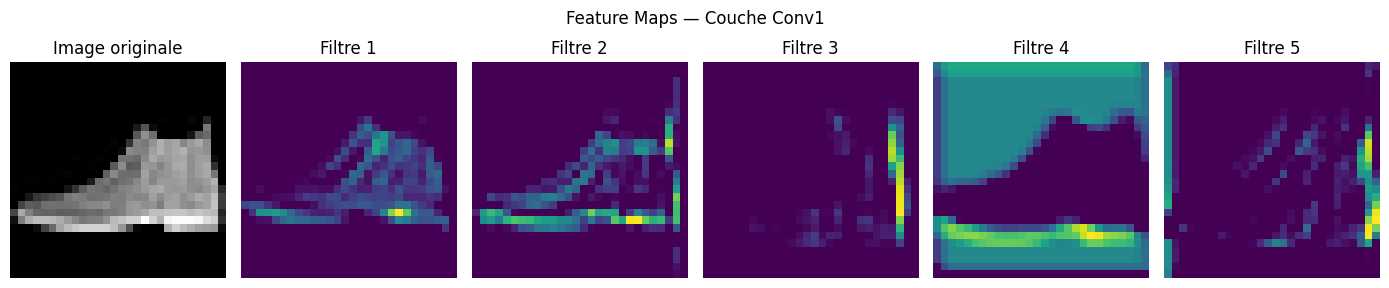

In [12]:
# === CELLULE 7 : Visualisation des cartes de caractéristiques ===

cnn.eval()
sample_img = next(iter(test_loader))[0][0:1].to(device)

# Extraction des activations de la première couche conv
with torch.no_grad():
    feat_maps = torch.relu(cnn.conv1(sample_img))  # (1, 6, 28, 28)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
axes[0].imshow(sample_img[0,0].cpu(), cmap='gray')
axes[0].set_title('Image originale')
for i in range(1, 6):
    axes[i].imshow(feat_maps[0, i-1].cpu(), cmap='viridis')
    axes[i].set_title(f'Filtre {i}')
for ax in axes: ax.axis('off')
plt.suptitle('Feature Maps — Couche Conv1'); plt.tight_layout(); plt.show()
